# NLP: Multinomial Naïve Bayes

Análise de sentimento em avaliações de produtos (TF-IDF + MultinomialNB).

Etapas adicionadas: **matriz de confusão (gráfico)**, **curva ROC**, **gravação do modelo (pipeline) em arquivo (.pkl)** e um **app Streamlit** de exemplo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

In [2]:
# 1. Geração da massa de dados de texto (Exemplo: Avaliações de Produtos)
textos = [
    "Excelente produto, entrega rápida e ótimo atendimento",
    "Gostei muito, superou minhas expectativas e chegou antes do prazo",
    "Muito bom, recomendo a todos a compra",
    "Qualidade excelente, comprarei novamente com certeza",
    "Produto maravilhoso, cumpre o que promete",
    "Péssima qualidade, veio com defeito e quebrado",
    "Pior compra que já fiz, não recomendo a ninguém",
    "Horrível, o produto demorou semanas e veio errado",
    "Muito insatisfeito, atendimento péssimo e sem suporte",
    "Não funciona direito, dinheiro jogado fora"
] * 20  # Multiplicando para gerar 200 amostras sintéticas

# Rótulos: 1 = Positivo, 0 = Negativo
labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0] * 20

df = pd.DataFrame({'texto': textos, 'sentimento': labels})

In [3]:
# 2. Divisão dos dados em treino (75%) e teste (25%)
X_train, X_test, y_train, y_test = train_test_split(
    df['texto'],
    df['sentimento'],
    test_size=0.25,
    random_state=42,
    stratify=df['sentimento']
)

In [4]:
# 3. Construção da Pipeline NLP (TF-IDF + MultinomialNB)
# CountVectorizer / TfidfVectorizer converte os textos em matrizes numéricas
pipeline_nlp = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,         # Converte texto para minúsculas
        ngram_range=(1, 2),     # Considera unigramas e bigramas (ex: "muito bom")
        strip_accents='unicode' # Remove acentos
    )),
    ('classifier', MultinomialNB(alpha=1.0)) # Alpha = parâmetro de suavização (Laplace Smoothing)
])

In [5]:
# 4. Treinamento do Modelo
pipeline_nlp.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), strip_accents='unicode')),
                ('classifier', MultinomialNB())])

In [6]:
# 5. Avaliação
y_pred = pipeline_nlp.predict(X_test)
y_proba = pipeline_nlp.predict_proba(X_test)[:, 1]

print("=== NLP: Multinomial Naïve Bayes ===")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

=== NLP: Multinomial Naïve Bayes ===
Matriz de Confusão:
[[25  0]
 [ 0 25]]

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00        25
    Positivo       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



## Matriz de Confusão (gráfico)

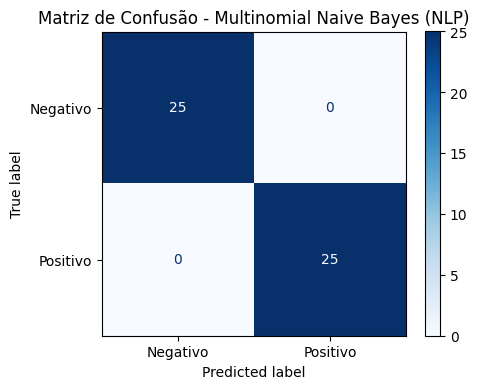

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Negativo", "Positivo"]).plot(ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusão - Multinomial Naive Bayes (NLP)")
plt.tight_layout()
plt.show()

## Curva ROC

AUC: 1.0000


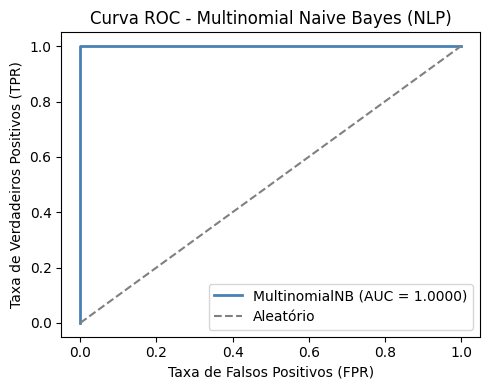

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"MultinomialNB (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax.set_title("Curva ROC - Multinomial Naive Bayes (NLP)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
# 6. Testando com novos textos inéditos
novos_exemplos = [
    "O suporte respondeu rápido e resolveu meu problema, gostei",
    "Veio quebrado e o atendimento foi horrível",
    "Chegou rápido, mas a qualidade é bem fraca"
]

predicoes = pipeline_nlp.predict(novos_exemplos)
probas = pipeline_nlp.predict_proba(novos_exemplos)

print("\n=== Predição em Novos Textos ===")
for texto, pred, prob in zip(novos_exemplos, predicoes, probas):
    classe = "Positivo" if pred == 1 else "Negativo"
    confianca = np.max(prob) * 100
    print(f"Texto: '{texto}'")
    print(f"-> Classe: {classe} ({confianca:.1f}% de confiança)\n")


=== Predição em Novos Textos ===
Texto: 'O suporte respondeu rápido e resolveu meu problema, gostei'
-> Classe: Negativo (54.6% de confiança)

Texto: 'Veio quebrado e o atendimento foi horrível'
-> Classe: Negativo (94.6% de confiança)

Texto: 'Chegou rápido, mas a qualidade é bem fraca'
-> Classe: Positivo (77.3% de confiança)



## Gravar o modelo (pipeline completo em arquivo .pkl)

In [10]:
with open("modelo_03_multinomialnb.pkl", "wb") as f:
    pickle.dump(pipeline_nlp, f)

print("Modelo salvo em modelo_03_multinomialnb.pkl")

Modelo salvo em modelo_03_multinomialnb.pkl
